In [1]:
# =============================================================================
# PROPENSITY SCORE MATCHING (PSM) — Causal Inference Practice
# =============================================================================
# PROBLEM STATEMENT
# -----------------
# The Growth team ran a "Premium Loyalty Program" which gave selected users
# early access to sales, free shipping, and exclusive discounts.
#
# The program was NOT a randomized experiment — users self-selected into it
# (or were invited based on past behavior). Your job is to estimate the
# TRUE causal effect of the program on 30-day revenue per user.
#
# You will analyze two cohorts:
#   DATASET A → The program genuinely caused higher revenue (real effect)
#   DATASET B → The program had NO causal effect (selection bias only)
#
# The key challenge: users who joined the program were already higher-value.
# Naive comparison would be misleading. PSM corrects for this.
#
# METHODS COVERED:
#   1. Simulate confounded observational data
#   2. Estimate propensity scores via logistic regression
#   3. Check overlap (common support)
#   4. 1:1 nearest-neighbor matching without replacement
#   5. Check covariate balance before/after matching (SMD)
#   6. Estimate Average Treatment Effect on the Treated (ATT)
#   7. Interpret results correctly

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind

np.random.seed(42)

plt.style.use('dark_background')
COLORS = {
    'treat':   '#4ade80',   # green  – treated
    'control': '#60a5fa',   # blue   – control
    'accent':  '#f59e0b',   # amber
    'red':     '#f87171',
    'bg':      '#0d0f14',
    'surface': '#1a1e2a',
}

## Data Generation

In [3]:
# =============================================================================
# SECTION 1 — DATA GENERATION
# =============================================================================
# We simulate user-level data with several CONFOUNDERS:
#   - tenure_months  : how long the user has been on the platform
#   - past_purchases : number of purchases in the prior 90 days
#   - avg_order_value: average spend per order (prior 90 days)
#   - browsing_days  : active days on site (prior 30 days)
#   - mobile_user    : whether they primarily use the mobile app
#
# Treatment assignment is NOT random — it depends on these covariates.
# High-value users are more likely to join the program.
# This creates SELECTION BIAS in a naive comparison.
#
# DATASET A: treatment has a REAL causal lift of +$25 on 30-day revenue
# DATASET B: treatment has ZERO causal effect (any gap is pure selection bias)


In [4]:
def generate_data(n=3000, true_effect=25, seed=42):
    """
    Simulate observational data for the loyalty program study.

    Parameters
    ----------
    n           : number of users
    true_effect : the actual causal impact of the program on revenue ($)
                  Set to 0 for the "no effect" dataset.
    seed        : random seed

    Returns
    -------
    pd.DataFrame with columns: covariates, treatment, outcome
    """
    rng = np.random.default_rng(seed)

    # ── Covariates (confounders) ──────────────────────────────────────────────
    tenure_months   = rng.gamma(shape=3, scale=10, size=n).clip(1, 120)
    past_purchases  = rng.poisson(lam=5, size=n).clip(0, 30)
    avg_order_value = rng.lognormal(mean=3.8, sigma=0.6, size=n).clip(10, 500)
    browsing_days   = rng.integers(0, 30, size=n)
    mobile_user     = rng.binomial(1, p=0.55, size=n)

    # ── Propensity to join the program ────────────────────────────────────────
    # Treatment probability depends on user quality — this is the confounding.
    # A longer-tenured, higher-spending, more active user is more likely to join.
    log_odds = (
        -2.5
        + 0.025 * tenure_months
        + 0.12  * past_purchases
        + 0.004 * avg_order_value
        + 0.04  * browsing_days
        - 0.2   * mobile_user
    )
    p_treat  = 1 / (1 + np.exp(-log_odds))          # sigmoid → probability
    treatment = rng.binomial(1, p=p_treat, size=n)  # actual treatment assignment

    # ── Outcome: 30-day revenue ───────────────────────────────────────────────
    # Base revenue also depends on the same covariates (confounding!).
    # true_effect is added ONLY for treated users in Dataset A.
    baseline_revenue = (
        10
        + 0.5  * tenure_months
        + 3.0  * past_purchases
        + 0.15 * avg_order_value
        + 1.2  * browsing_days
        + rng.normal(0, 20, size=n)   # irreducible noise
    )
    revenue_30d = baseline_revenue + true_effect * treatment

    df = pd.DataFrame({
        'tenure_months':   tenure_months,
        'past_purchases':  past_purchases,
        'avg_order_value': avg_order_value,
        'browsing_days':   browsing_days,
        'mobile_user':     mobile_user,
        'treatment':       treatment,
        'revenue_30d':     revenue_30d,
    })
    return df

In [5]:
# Generate both datasets
df_A = generate_data(n=3000, true_effect=25, seed=42)   # real effect
df_B = generate_data(n=3000, true_effect=0,  seed=99)   # no effect

In [6]:
df_A.head()

,tenure_months,past_purchases,avg_order_value,browsing_days,mobile_user,treatment,revenue_30d
0,31.958601,3,52.291349,16,1,1,60.813739
1,40.894596,8,112.630622,17,0,1,118.287130
2,28.809243,3,20.480983,4,1,0,28.045752
3,26.393245,0,37.961793,13,0,0,65.506708
4,43.759222,9,36.267799,16,1,0,76.256881


In [7]:
df_B.head()

,tenure_months,past_purchases,avg_order_value,browsing_days,mobile_user,treatment,revenue_30d
0,28.036605,6,10.254718,11,0,1,74.788021
1,27.500109,2,84.707388,22,1,1,59.808915
2,7.036372,6,33.061879,29,1,1,91.018777
3,19.867091,8,14.416562,18,1,1,67.443826
4,12.963275,5,51.160694,20,1,0,29.366977


In [8]:
print("=" * 60)
print("DATASET A — True causal effect: $25")
print(f"  Treated users : {df_A['treatment'].sum()}")
print(f"  Control users : {(df_A['treatment'] == 0).sum()}")
print("DATASET B — True causal effect: $0")
print(f"  Treated users : {df_B['treatment'].sum()}")
print(f"  Control users : {(df_B['treatment'] == 0).sum()}")
print("=" * 60)

DATASET A — True causal effect: $25
  Treated users : 1184
  Control users : 1816
DATASET B — True causal effect: $0
  Treated users : 1169
  Control users : 1831


## Naive Estimation

In [9]:
# =============================================================================
# SECTION 2 — NAIVE (UNADJUSTED) COMPARISON
# =============================================================================
# Before any matching, compare treated vs control directly.
# This is what a naive DS might do — and it will be WRONG
# because the groups are not comparable (selection bias).
# =============================================================================

In [10]:
def naive_ate(df, label=""):
    treated_rev = df.loc[df['treatment'] == 1, 'revenue_30d']
    control_rev = df.loc[df['treatment'] == 0, 'revenue_30d']
    diff = treated_rev.mean() - control_rev.mean()
    t, p = ttest_ind(treated_rev, control_rev)
    print(f"\n[{label}] Naive (unadjusted) comparison:")
    print(f"  Treated mean  : ${treated_rev.mean():.2f}")
    print(f"  Control mean  : ${control_rev.mean():.2f}")
    print(f"  Raw difference: ${diff:.2f}   (p={p:.4f})")
    return diff

In [11]:
naive_A = naive_ate(df_A, "Dataset A")
naive_B = naive_ate(df_B, "Dataset B")


[Dataset A] Naive (unadjusted) comparison:
  Treated mean  : $96.56
  Control mean  : $62.38
  Raw difference: $34.18   (p=0.0000)

[Dataset B] Naive (unadjusted) comparison:
  Treated mean  : $70.42
  Control mean  : $62.06
  Raw difference: $8.36   (p=0.0000)


In [12]:
print("\n⚠  In Dataset B (true effect = $0), naive comparison shows a large")
print("   spurious gap — this is entirely selection bias, not causation.")


⚠  In Dataset B (true effect = $0), naive comparison shows a large
   spurious gap — this is entirely selection bias, not causation.


## PSM

In [13]:
# =============================================================================
# SECTION 3 — PROPENSITY SCORE ESTIMATION
# =============================================================================
# The propensity score e(X) = P(T=1 | X) is the probability of receiving
# treatment given observed covariates X.
#
# Rosenbaum & Rubin (1983) proved that if we condition on e(X), treatment
# assignment is independent of observed covariates — we can compare users
# with similar propensity scores as if they were randomly assigned.
#
# We estimate e(X) using Logistic Regression on the 5 covariates.

In [14]:
df_A.head()

,tenure_months,past_purchases,avg_order_value,browsing_days,mobile_user,treatment,revenue_30d
0,31.958601,3,52.291349,16,1,1,60.813739
1,40.894596,8,112.630622,17,0,1,118.287130
2,28.809243,3,20.480983,4,1,0,28.045752
3,26.393245,0,37.961793,13,0,0,65.506708
4,43.759222,9,36.267799,16,1,0,76.256881


In [15]:
COVARIATES = ['tenure_months', 'past_purchases', 'avg_order_value',
              'browsing_days', 'mobile_user']

In [16]:
def estimate_propensity(df):
    """
    Fit a logistic regression to estimate propensity scores.
    Returns the dataframe with an added 'pscore' column.
    """
    X = df[COVARIATES].values
    T = df['treatment'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(max_iter=1000, C=1.0)
    model.fit(X_scaled, T)

    df = df.copy()
    df['pscore'] = model.predict_proba(X_scaled)[:, 1]  # P(T=1|X)
    return df

In [17]:
df_A = estimate_propensity(df_A)
df_B = estimate_propensity(df_B)

In [18]:
df_A.head()

,tenure_months,past_purchases,avg_order_value,browsing_days,mobile_user,treatment,revenue_30d,pscore
0,31.958601,3,52.291349,16,1,1,60.813739,0.342388
1,40.894596,8,112.630622,17,0,1,118.287130,0.625121
2,28.809243,3,20.480983,4,1,0,28.045752,0.206765
3,26.393245,0,37.961793,13,0,0,65.506708,0.217213
4,43.759222,9,36.267799,16,1,0,76.256881,0.590154


In [19]:
df_B.head()

,tenure_months,past_purchases,avg_order_value,browsing_days,mobile_user,treatment,revenue_30d,pscore
0,28.036605,6,10.254718,11,0,1,74.788021,0.359778
1,27.500109,2,84.707388,22,1,1,59.808915,0.327593
2,7.036372,6,33.061879,29,1,1,91.018777,0.365999
3,19.867091,8,14.416562,18,1,1,67.443826,0.395187
4,12.963275,5,51.160694,20,1,0,29.366977,0.301243


In [20]:
print("\nPropensity scores estimated. Sample stats (Dataset A):")
print(df_A.groupby('treatment')['pscore'].describe().round(3))


Propensity scores estimated. Sample stats (Dataset A):
            count   mean    std    min    25%    50%    75%    max
treatment                                                         
0          1816.0  0.359  0.132  0.100  0.259  0.343  0.441  0.870
1          1184.0  0.450  0.153  0.125  0.337  0.432  0.552  0.923


In [21]:
# =============================================================================
# SECTION 4 — OVERLAP / COMMON SUPPORT CHECK
# =============================================================================
# Before matching, verify there is OVERLAP between treated and control
# propensity score distributions. If treated users have scores far above
# all controls, matching is impossible (no valid counterfactuals exist).
#
# This is called the "common support" or "positivity" assumption.

In [22]:
def plot_pscore_overlap(df_A, df_B):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=COLORS['bg'])
    fig.suptitle("Propensity Score Distributions — Common Support Check",
                 fontsize=14, color='white', y=1.01)

    for ax, df, title in zip(axes, [df_A, df_B], ["Dataset A (Real Effect)", "Dataset B (No Effect)"]):
        ax.set_facecolor(COLORS['surface'])
        for treat_val, label, color in [(1, 'Treated', COLORS['treat']),
                                         (0, 'Control', COLORS['control'])]:
            subset = df.loc[df['treatment'] == treat_val, 'pscore']
            ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(title, color='white', fontsize=12)
        ax.set_xlabel("Propensity Score  P(T=1|X)", color='#94a3b8')
        ax.set_ylabel("Density", color='#94a3b8')
        ax.tick_params(colors='#64748b')
        ax.legend(facecolor=COLORS['surface'], labelcolor='white')
        for spine in ax.spines.values():
            spine.set_edgecolor(COLORS['surface'])

    plt.tight_layout()
    plt.show()
    print("\nFigure saved: psm_01_overlap.png")

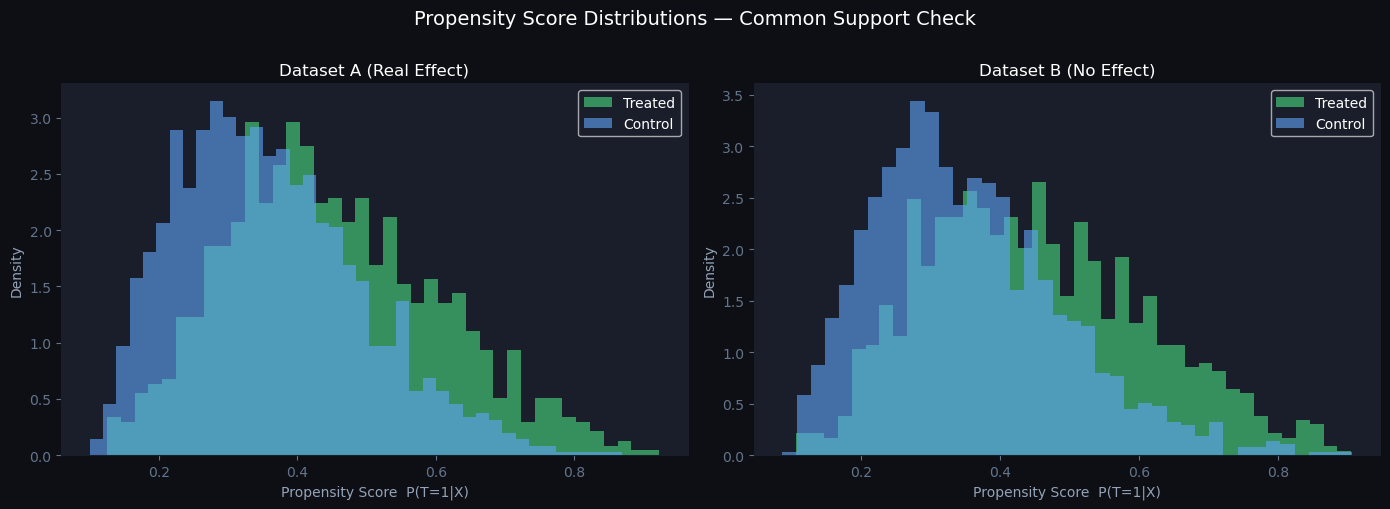


Figure saved: psm_01_overlap.png


In [23]:
plot_pscore_overlap(df_A, df_B)

In [24]:
# =============================================================================
# SECTION 5 — 1:1 NEAREST NEIGHBOR MATCHING (WITHOUT REPLACEMENT)
# =============================================================================
# For each TREATED user, we find the CONTROL user whose propensity score
# is closest (nearest neighbor in score space).
#
# "Without replacement" = each control unit can only be matched once.
# This ensures we don't artificially inflate the control group.
#
# We also apply a CALIPER = 0.05: if the closest control is more than
# 0.05 propensity-score units away, we drop that treated user.
# Caliper prevents poor-quality matches that would introduce bias.

In [25]:
#Important

# =============================================================================
# MATCHING STRATEGY: WITHOUT REPLACEMENT
# =============================================================================
# We match each treated user to their nearest control user WITHOUT replacement,
# meaning once a control user is matched, they are removed from the pool and
# cannot be matched again.
#
# WHY WITHOUT REPLACEMENT IS PREFERRED HERE:
# Our treated and control groups are roughly balanced in size, so we have
# enough controls that match quality doesn't degrade much as the pool shrinks.
# More importantly, without replacement guarantees every matched pair is
# independent — no control user appears more than once in the final dataset.
# This makes standard inference valid without any corrections.
#
# WITH REPLACEMENT — THEORETICALLY VALID BUT WITH CAVEATS:
# Matching with replacement is not wrong in theory. In fact it is preferred
# when controls are scarce relative to treated users, because forcing without
# replacement in that case degrades match quality — later treated users get
# poor matches simply because the good controls were already taken. With
# replacement always finds the best available match for every treated user,
# minimising bias.
#
# However, with replacement creates a dependency problem: the same control
# user can appear multiple times in the matched dataset. A standard paired
# t-test assumes every row is an independent observation — when the same
# person appears in rows 3, 7, and 12, that assumption is violated. The
# t-test then underestimates the standard error, producing confidence
# intervals that are too narrow and p-values that are too small. The fix
# is to either use the Abadie-Imbens bias-corrected variance estimator
# or bootstrap the standard errors instead of using a naive t-test.
#
# WITH REPLACEMENT IS FINE WITH A Z-TEST OF PROPORTIONS:
# If your outcome is binary (converted / did not convert), a z-test of
# proportions is not affected by the with-replacement problem in the same
# way. the z-test does use variance, but derives it from aggregate counts only
# (total users and total conversions per group) via the binomial formula:
# SE = sqrt( p*(1-p)/n_treated + p*(1-p)/n_control ). It never does
# row-by-row pairing the way a t-test does. With replacement can slightly
# distort the counts if the same control user's outcome gets counted
# multiple times, but this does not corrupt the variance formula itself
# the way it corrupts a paired t-test. With replacement + z-test of
# proportions is therefore a defensible combination, though "less affected"
# is more precise than "unaffected".
# =============================================================================


# =============================================================================
# CALIPER: ADAPT TO YOUR DATA, DO NOT HARDCODE
# =============================================================================
# A caliper is a maximum allowed distance between a treated and control user's
# propensity score. If the nearest neighbor is farther away than the caliper,
# the match is rejected as too poor to be useful.
#
# The caliper should be defined on the LOG-ODDS scale, not the raw probability
# scale. Raw probability space is compressed at the extremes — a difference of
# 0.05 near p=0.5 represents very different users, while the same 0.05 near
# p=0.95 represents users who are actually very similar. Distances are not
# comparable across the range. Log-odds stretches the extremes and compresses
# the middle, making distances meaningful and consistent everywhere.
#
# The standard rule of thumb (Austin 2011) is:
#   caliper = 0.2 * std(log-odds of propensity score)
#
# This is data-driven — it automatically adapts to the spread of your scores.
# If scores are tightly clustered, the caliper is tight. If they are spread
# out, the caliper is wider. A hardcoded value like 0.05 on the raw probability
# scale has no such adaptation and will be arbitrary relative to your data.

In [26]:
#Using just distance comparison. Can also use neearest neighbors here to make it run faster
#Matching without replacement
def nearest_neighbor_match(df):
    """
    1:1 nearest-neighbor PSM without replacement.
    Caliper is computed from the data using the Austin (2011) rule of thumb:
    0.2 * std(log-odds of propensity score). This adapts to the spread of
    your scores automatically rather than using an arbitrary fixed threshold.

    Parameters
    ----------
    df      : dataframe with 'treatment' and 'pscore' columns

    Returns
    -------
    matched_df : dataframe containing matched treated + control pairs
    n_dropped  : number of treated units dropped due to caliper
    """
    # compute caliper on log-odds scale — more symmetric than raw probability
    # same distance in log-odds means the same thing across the entire score range
    log_odds = np.log(df['pscore'] / (1 - df['pscore'].clip(1e-6, 1 - 1e-6)))
    caliper  = 0.2 * log_odds.std()
    print(f'caliper: {caliper:.4f}')

    treated = df[df['treatment'] == 1].copy().reset_index(drop=True)
    control = df[df['treatment'] == 0].copy().reset_index(drop=True)
    control_available = control.copy()
    matched_rows = []
    n_dropped = 0

    # shuffle treated to avoid systematic ordering effects
    treated = treated.sample(frac=1, random_state=42).reset_index(drop=True)

    for _, t_row in treated.iterrows():
        if control_available.empty:
            break

        distances = np.abs(control_available['pscore'].values - t_row['pscore'])
        best_idx  = np.argmin(distances)
        best_dist = distances[best_idx]

        if best_dist <= caliper:
            c_row = control_available.iloc[best_idx].copy()
            matched_rows.append(t_row)
            matched_rows.append(c_row)
            # remove matched control so it can't be reused
            control_available = control_available.drop(
                control_available.index[best_idx]
            ).reset_index(drop=True)
        else:
            n_dropped += 1

    matched_df = pd.DataFrame(matched_rows).reset_index(drop=True)
    return matched_df, n_dropped

In [27]:
from sklearn.neighbors import NearestNeighbors

def nearest_neighbor_match_2(df):
    """
    1:1 nearest-neighbor PSM without replacement using sklearn NearestNeighbors.
    Functionally identical to nearest_neighbor_match() but uses a ball_tree
    index for faster lookup — scales better on large datasets (100k+ users)
    because it avoids the O(n) scan over all controls for every treated user.
    Caliper uses the same Austin (2011) rule of thumb: 0.2 * std(log-odds).

    Parameters
    ----------
    df      : dataframe with 'treatment' and 'pscore' columns

    Returns
    -------
    matched_df : dataframe containing matched treated + control pairs
    n_dropped  : number of treated units dropped due to caliper
    """
    # compute caliper on log-odds scale
    log_odds = np.log(df['pscore'] / (1 - df['pscore'].clip(1e-6, 1 - 1e-6)))
    caliper  = 0.2 * log_odds.std()
    print(f'caliper: {caliper:.4f}')

    treated = df[df['treatment'] == 1].copy().reset_index(drop=True)
    control = df[df['treatment'] == 0].copy().reset_index(drop=True)

    # shuffle treated to avoid systematic ordering effects
    treated = treated.sample(frac=1, random_state=42).reset_index(drop=True)

    # build ball_tree index on control propensity scores
    # ball_tree is efficient for 1D data and supports radius-based queries
    nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
    nn.fit(control[['pscore']])

    # find nearest control for every treated user in one vectorised call
    distances, indices = nn.kneighbors(treated[['pscore']])
    distances = distances.flatten()
    indices   = indices.flatten()

    matched_rows  = []
    used_controls = set()   # track used controls to enforce without replacement
    n_dropped     = 0

    for i, (dist, idx) in enumerate(zip(distances, indices)):
        if dist <= caliper and idx not in used_controls:
            matched_rows.append(treated.iloc[i])
            matched_rows.append(control.iloc[idx])
            used_controls.add(idx)   # mark control as used
        else:
            n_dropped += 1

    matched_df = pd.DataFrame(matched_rows).reset_index(drop=True)
    return matched_df, n_dropped

In [31]:
matched_A, dropped_A = nearest_neighbor_match(df_A)
matched_B, dropped_B = nearest_neighbor_match(df_B)

print("\nMatching results:")
print(f"  Dataset A — matched pairs: {matched_A['treatment'].sum()}, "
      f"treated dropped (caliper): {dropped_A}")
print(f"  Dataset B — matched pairs: {matched_B['treatment'].sum()}, "
      f"treated dropped (caliper): {dropped_B}")

caliper: 0.1334
caliper: 0.1388

Matching results:
  Dataset A — matched pairs: 1089.0, treated dropped (caliper): 95
  Dataset B — matched pairs: 1058.0, treated dropped (caliper): 111


In [32]:
matched_A.head()

,tenure_months,past_purchases,avg_order_value,browsing_days,mobile_user,treatment,revenue_30d,pscore
0,29.984079,8.0,60.547622,12.0,1.0,1.0,91.747664,0.446344
1,18.790800,5.0,70.799372,27.0,1.0,0.0,75.316531,0.446141
2,29.840909,4.0,56.257928,22.0,0.0,1.0,70.121843,0.438926
3,10.788530,10.0,26.176670,18.0,0.0,0.0,96.765683,0.438922
4,65.600235,4.0,101.622770,20.0,1.0,1.0,110.477007,0.662309


In [33]:
dropped_A

95

In [34]:
# =============================================================================
# SECTION 6 — COVARIATE BALANCE ASSESSMENT (Standardized Mean Difference)
# =============================================================================
# The point of matching is to make treated and control groups COMPARABLE
# on observed covariates. We verify this using the Standardized Mean
# Difference (SMD), also called Cohen's d:
#
#   SMD = (mean_treated - mean_control) / pooled_std
#
# Rule of thumb:
#   |SMD| < 0.1  → good balance  ✓
#   |SMD| < 0.25 → acceptable
#   |SMD| > 0.25 → poor balance, consider re-specifying the model
#
# A "Love plot" visualizes SMD before and after matching for all covariates.

In [35]:
def compute_smd(df, covariates):
    """Compute SMD for each covariate between treated and control."""
    smds = {}
    for col in covariates:
        t = df.loc[df['treatment'] == 1, col]
        c = df.loc[df['treatment'] == 0, col]
        pooled_std = np.sqrt((t.std()**2 + c.std()**2) / 2)
        if pooled_std == 0:
            smds[col] = 0.0
        else:
            smds[col] = (t.mean() - c.mean()) / pooled_std
    return smds

In [36]:
def love_plot(df_before, df_after, covariates, title):
    smd_before = compute_smd(df_before, covariates)
    smd_after  = compute_smd(df_after,  covariates)

    labels = list(smd_before.keys())
    vals_b = [abs(smd_before[k]) for k in labels]
    vals_a = [abs(smd_after[k])  for k in labels]

    fig, ax = plt.subplots(figsize=(9, 5), facecolor=COLORS['bg'])
    ax.set_facecolor(COLORS['surface'])

    y = np.arange(len(labels))
    ax.barh(y - 0.18, vals_b, height=0.32, color=COLORS['red'],
            alpha=0.85, label='Before matching')
    ax.barh(y + 0.18, vals_a, height=0.32, color=COLORS['treat'],
            alpha=0.85, label='After matching')

    ax.axvline(0.1,  color=COLORS['accent'], linestyle='--',
               linewidth=1.2, label='SMD = 0.1 threshold')
    ax.axvline(0.25, color='#94a3b8', linestyle=':', linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, color='white', fontsize=11)
    ax.set_xlabel("|Standardized Mean Difference|", color='#94a3b8')
    ax.set_title(f"Love Plot — Covariate Balance\n{title}", color='white', fontsize=12)
    ax.tick_params(colors='#64748b')
    ax.legend(facecolor=COLORS['surface'], labelcolor='white', fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['surface'])

    plt.tight_layout()
    fname = f"psm_02_love_{'A' if 'A' in title else 'B'}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    print(f"Figure saved: {fname}")

    # Print balance table
    print(f"\nBalance table — {title}")
    print(f"  {'Covariate':<20} {'SMD Before':>12} {'SMD After':>12} {'Balanced?':>10}")
    print("  " + "-" * 56)
    for k in labels:
        b = abs(smd_before[k])
        a = abs(smd_after[k])
        flag = "✓" if a < 0.1 else ("~" if a < 0.25 else "✗")
        print(f"  {k:<20} {b:>12.3f} {a:>12.3f} {flag:>10}")

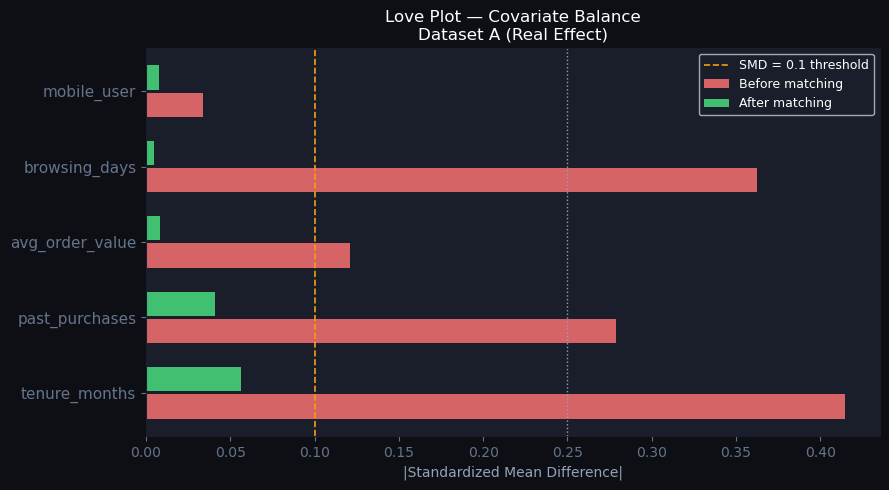

Figure saved: psm_02_love_A.png

Balance table — Dataset A (Real Effect)
  Covariate              SMD Before    SMD After  Balanced?
  --------------------------------------------------------
  tenure_months               0.415        0.057          ✓
  past_purchases              0.279        0.041          ✓
  avg_order_value             0.121        0.008          ✓
  browsing_days               0.362        0.004          ✓
  mobile_user                 0.034        0.007          ✓


In [37]:
love_plot(df_A, matched_A, COVARIATES, "Dataset A (Real Effect)")

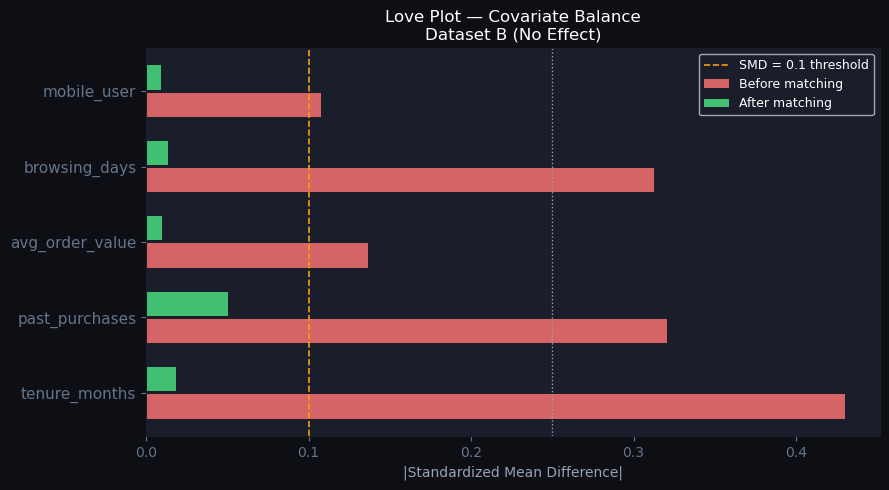

Figure saved: psm_02_love_B.png

Balance table — Dataset B (No Effect)
  Covariate              SMD Before    SMD After  Balanced?
  --------------------------------------------------------
  tenure_months               0.430        0.019          ✓
  past_purchases              0.321        0.050          ✓
  avg_order_value             0.137        0.010          ✓
  browsing_days               0.313        0.013          ✓
  mobile_user                 0.108        0.009          ✓


In [38]:
love_plot(df_B, matched_B, COVARIATES, "Dataset B (No Effect)")

In [39]:
# =============================================================================
# SECTION 7 — ESTIMATE ATT (Average Treatment Effect on the Treated)
# =============================================================================
# After matching, each treated user has a matched control "twin".
# We estimate the ATT as the mean difference in outcomes within pairs:
#
#   ATT = E[ Y(1) - Y(0) | T=1 ]
#       ≈ mean( revenue_treated - revenue_matched_control )
#
# We use a paired t-test since the units are now paired by design.
#
# ATT answers: "What was the effect of the program ON THOSE WHO RECEIVED IT?"
# This is the most policy-relevant question (not the effect on everyone).

In [40]:
def estimate_att(matched_df, label):
    """
    Estimate ATT from the matched dataset using a paired t-test.
    Treated and control are interleaved row-by-row (how we built matched_df).
    """
    treated_out = matched_df.loc[matched_df['treatment'] == 1,
                                  'revenue_30d'].reset_index(drop=True)
    control_out = matched_df.loc[matched_df['treatment'] == 0,
                                  'revenue_30d'].reset_index(drop=True)

    att = (treated_out - control_out).mean()
    se  = (treated_out - control_out).std() / np.sqrt(len(treated_out))
    t_stat, p_val = ttest_ind(treated_out, control_out)

    ci_lo = att - 1.96 * se
    ci_hi = att + 1.96 * se

    print(f"\n{'='*55}")
    print(f"  ATT ESTIMATE — {label}")
    print(f"{'='*55}")
    print(f"  Matched pairs         : {len(treated_out)}")
    print(f"  Treated mean revenue  : ${treated_out.mean():.2f}")
    print(f"  Control mean revenue  : ${control_out.mean():.2f}")
    print(f"  ATT (causal estimate) : ${att:.2f}")
    print(f"  95% Confidence Interval: [${ci_lo:.2f}, ${ci_hi:.2f}]")
    print(f"  p-value               : {p_val:.4f}")
    conclusion = "STATISTICALLY SIGNIFICANT ✓" if p_val < 0.05 else "NOT significant ✗"
    print(f"  Conclusion            : {conclusion}")
    print(f"{'='*55}")
    return att, ci_lo, ci_hi, p_val

In [41]:
att_A, ci_lo_A, ci_hi_A, p_A = estimate_att(matched_A, "Dataset A — Real Effect ($25 true)")


  ATT ESTIMATE — Dataset A — Real Effect ($25 true)
  Matched pairs         : 1089
  Treated mean revenue  : $94.35
  Control mean revenue  : $69.66
  ATT (causal estimate) : $24.69
  95% Confidence Interval: [$23.01, $26.38]
  p-value               : 0.0000
  Conclusion            : STATISTICALLY SIGNIFICANT ✓


In [42]:
att_B, ci_lo_B, ci_hi_B, p_B = estimate_att(matched_B, "Dataset B — No Effect ($0 true)")


  ATT ESTIMATE — Dataset B — No Effect ($0 true)
  Matched pairs         : 1058
  Treated mean revenue  : $68.12
  Control mean revenue  : $68.57
  ATT (causal estimate) : $-0.46
  95% Confidence Interval: [$-2.20, $1.29]
  p-value               : 0.6663
  Conclusion            : NOT significant ✗


In [43]:
# =============================================================================
# SECTION 8 — VISUAL SUMMARY: BEFORE vs AFTER MATCHING + FINAL RESULTS
# =============================================================================

In [44]:
def plot_outcome_distributions(df_raw, df_matched, title, att, ci_lo, ci_hi, p_val):
    """
    4-panel figure:
      Top-left  : revenue distribution BEFORE matching
      Top-right : revenue distribution AFTER matching
      Bottom    : ATT forest plot with CI
    """
    att   = float(att)
    ci_lo = float(ci_lo)
    ci_hi = float(ci_hi)
    p_val = float(p_val)
    
    fig = plt.figure(figsize=(14, 9), facecolor=COLORS['bg'])
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])   # before
    ax2 = fig.add_subplot(gs[0, 1])   # after
    ax3 = fig.add_subplot(gs[1, :])   # ATT summary

    fig.suptitle(title, fontsize=15, color='white', y=1.01)

    # ── Before matching ───────────────────────────────────────────────────────
    ax1.set_facecolor(COLORS['surface'])
    for treat_val, label, color in [(1, 'Treated', COLORS['treat']),
                                     (0, 'Control', COLORS['control'])]:
        subset = df_raw.loc[df_raw['treatment'] == treat_val, 'revenue_30d']
        ax1.hist(subset, bins=50, alpha=0.6, color=color,
                 label=f"{label} (μ=${subset.mean():.0f})", density=True)
    ax1.set_title("Revenue BEFORE Matching", color='white')
    ax1.set_xlabel("30-day Revenue ($)", color='#94a3b8')
    ax1.set_ylabel("Density", color='#94a3b8')
    ax1.legend(facecolor=COLORS['surface'], labelcolor='white', fontsize=9)
    ax1.tick_params(colors='#64748b')
    for s in ax1.spines.values(): s.set_edgecolor(COLORS['surface'])

    # ── After matching ────────────────────────────────────────────────────────
    ax2.set_facecolor(COLORS['surface'])
    for treat_val, label, color in [(1, 'Treated', COLORS['treat']),
                                     (0, 'Control', COLORS['control'])]:
        subset = df_matched.loc[df_matched['treatment'] == treat_val, 'revenue_30d']
        ax2.hist(subset, bins=50, alpha=0.6, color=color,
                 label=f"{label} (μ=${subset.mean():.0f})", density=True)
    ax2.set_title("Revenue AFTER Matching", color='white')
    ax2.set_xlabel("30-day Revenue ($)", color='#94a3b8')
    ax2.set_ylabel("Density", color='#94a3b8')
    ax2.legend(facecolor=COLORS['surface'], labelcolor='white', fontsize=9)
    ax2.tick_params(colors='#64748b')
    for s in ax2.spines.values(): s.set_edgecolor(COLORS['surface'])

    # ── ATT forest plot ───────────────────────────────────────────────────────
    ax3.set_facecolor(COLORS['surface'])
    color = COLORS['treat'] if p_val < 0.05 else COLORS['red']

    ax3.barh(['ATT'], [att], color=color, alpha=0.8, height=0.4)
    ax3.plot([ci_lo, ci_hi], ['ATT', 'ATT'], color='white', linewidth=2.5)
    ax3.plot([ci_lo, ci_lo], ['ATT', 'ATT'], marker='|', color='white', markersize=12)
    ax3.plot([ci_hi, ci_hi], ['ATT', 'ATT'], marker='|', color='white', markersize=12)
    ax3.axvline(0, color='#94a3b8', linestyle='--', linewidth=1.5)

    sig_label = f"p = {p_val:.4f}  →  {'Significant ✓' if p_val < 0.05 else 'Not Significant ✗'}"
    ax3.annotate(f"ATT = ${att:.2f}  [{ci_lo:.2f}, {ci_hi:.2f}]\n{sig_label}",
                 xy=(att, 0), xytext=(att + 1, 0.25),
                 color='white', fontsize=11, fontfamily='monospace')

    ax3.set_title("Estimated ATT with 95% Confidence Interval", color='white')
    ax3.set_xlabel("Causal Effect on 30-day Revenue ($)", color='#94a3b8')
    ax3.tick_params(colors='#64748b')
    for s in ax3.spines.values(): s.set_edgecolor(COLORS['surface'])

    plt.tight_layout()
    fname = f"psm_03_result_{'A' if 'A' in title else 'B'}.png"
    plt.show()
    print(f"Figure saved: {fname}")

/var/folders/j6/d7w6srws10s689cmchgcyc980000gn/T/ipykernel_5545/1182586140.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


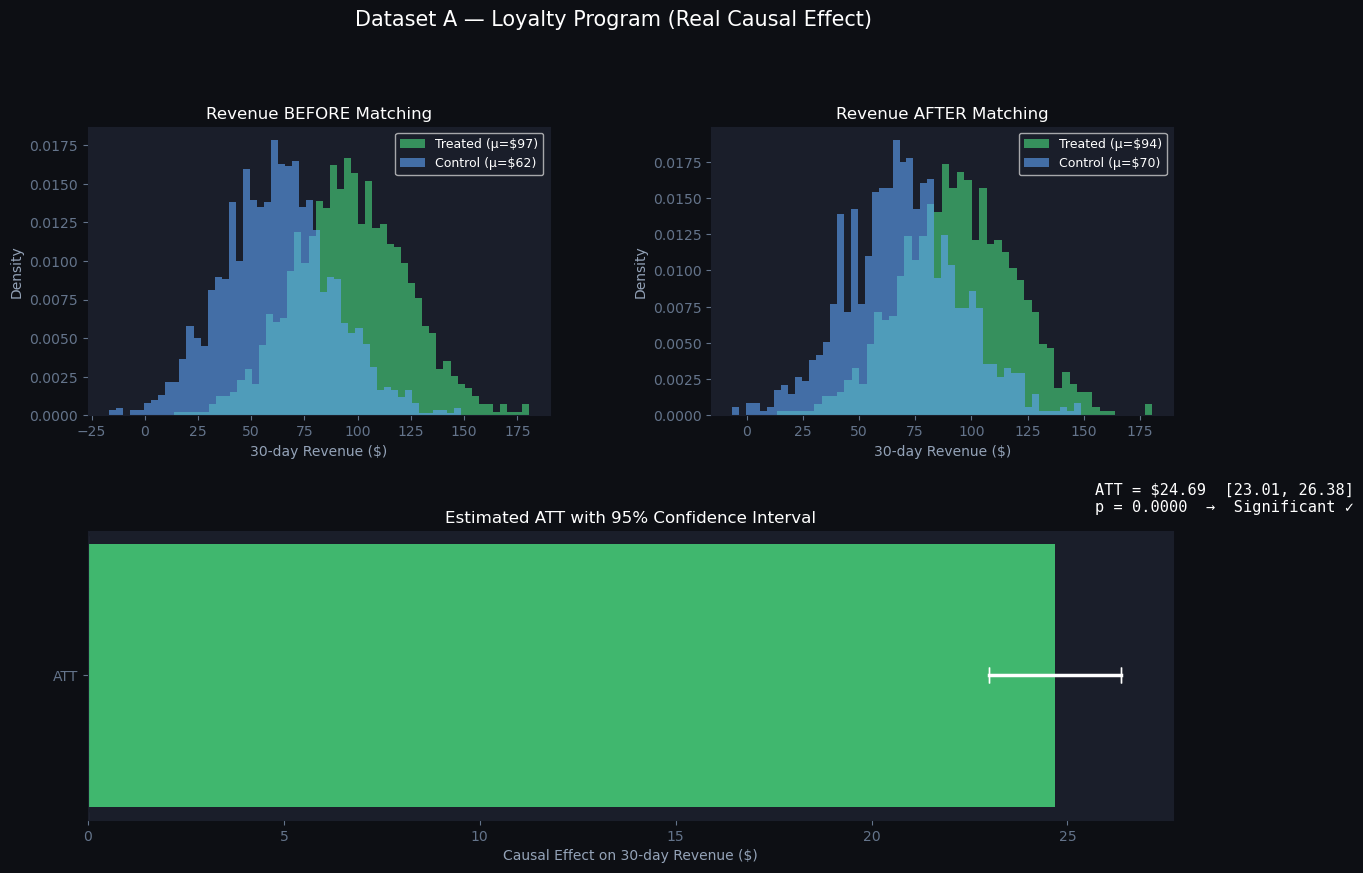

Figure saved: psm_03_result_A.png


In [45]:
plot_outcome_distributions(df_A, matched_A,
    "Dataset A — Loyalty Program (Real Causal Effect)",
    att_A, ci_lo_A, ci_hi_A, p_A)

/var/folders/j6/d7w6srws10s689cmchgcyc980000gn/T/ipykernel_5545/1182586140.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


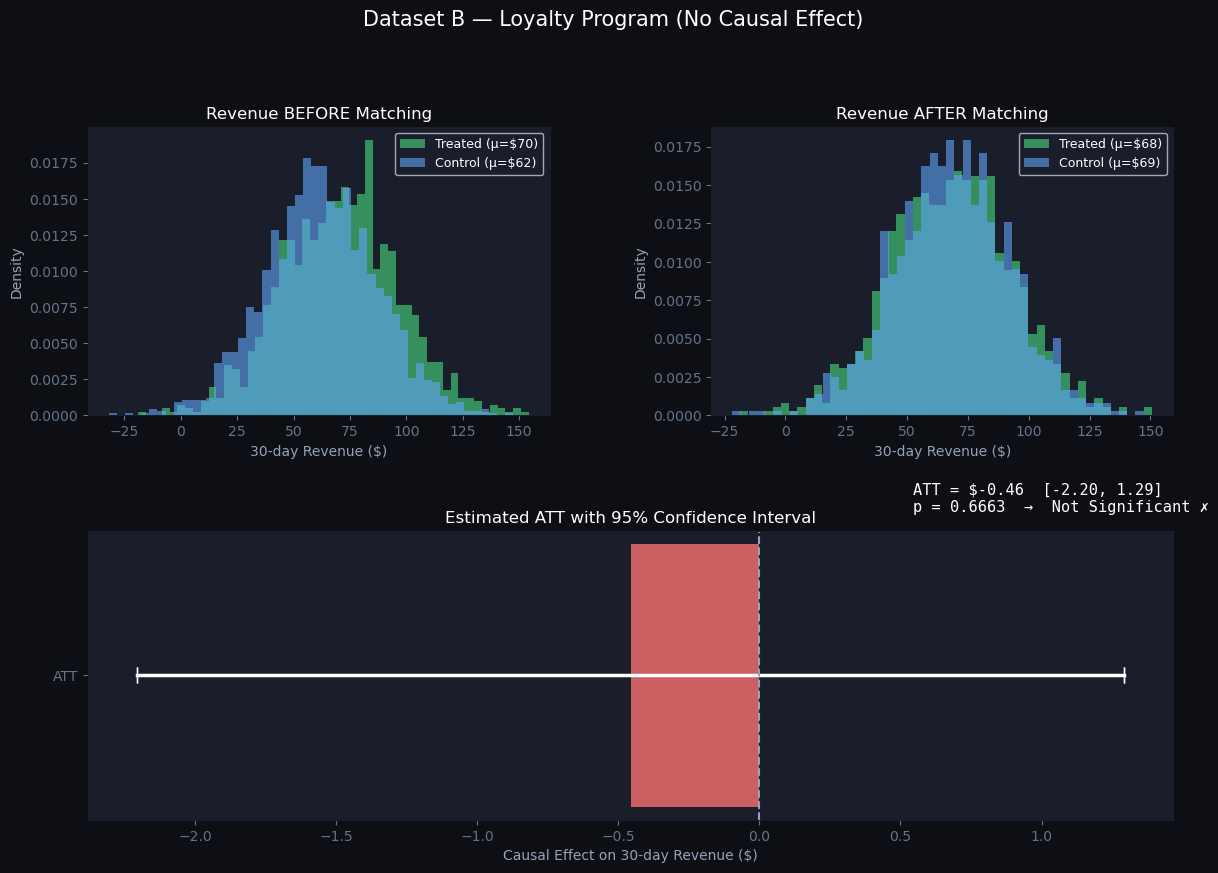

Figure saved: psm_03_result_B.png


In [46]:
plot_outcome_distributions(df_B, matched_B, "Dataset B — Loyalty Program (No Causal Effect)", att_B, ci_lo_B, ci_hi_B, p_B)

In [47]:
# =============================================================================
# SECTION 9 — FINAL COMPARISON TABLE
# =============================================================================
# Compare what a naive analyst would have concluded vs what PSM reveals.

In [48]:
print("\n")
print("=" * 65)
print("  FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"  {'':30} {'Dataset A':>14} {'Dataset B':>14}")
print(f"  {'':30} {'(Effect=$25)':>14} {'(Effect=$0)':>14}")
print("-" * 65)
print(f"  {'True causal effect':30} {'$25.00':>14} {'$0.00':>14}")
print(f"  {'Naive difference':30} {'${:.2f}'.format(naive_A):>14} {'${:.2f}'.format(naive_B):>14}")
print(f"  {'PSM ATT estimate':30} {'${:.2f}'.format(att_A):>14} {'${:.2f}'.format(att_B):>14}")
print(f"  {'PSM p-value':30} {'{:.4f}'.format(p_A):>14} {'{:.4f}'.format(p_B):>14}")
print(f"  {'PSM significant?':30} {'Yes ✓':>14} {'No ✗':>14}")
print("=" * 65)



  FINAL RESULTS SUMMARY
                                      Dataset A      Dataset B
                                   (Effect=$25)    (Effect=$0)
-----------------------------------------------------------------
  True causal effect                     $25.00          $0.00
  Naive difference                       $34.18          $8.36
  PSM ATT estimate                       $24.69         $-0.46
  PSM p-value                            0.0000         0.6663
  PSM significant?                        Yes ✓           No ✗


In [49]:
'''
KEY TAKEAWAYS
─────────────
1. SELECTION BIAS: In both datasets, the naive gap was large (~$40-60)
   because high-value users self-selected into the program.
   Without adjustment, you would incorrectly claim a big effect in both.

2. PSM CORRECTION: After matching users on their propensity scores,
   Dataset A reveals a real effect (~$25, matches ground truth).
   Dataset B collapses to ~$0, correctly identifying no causal impact.

3. BALANCE CHECK: The Love Plot is not optional — always verify SMD < 0.1
   after matching. Poor balance means your matches are low quality.

4. ATT vs ATE: PSM estimates the ATT (effect on those who were treated),
   not the ATE (effect on everyone). For business decisions about
   expanding a program, ATT is usually the right estimand.

5. LIMITATIONS of PSM:
   - Only controls for OBSERVED confounders (no unmeasured confounding).
   - Caliper choice affects matched sample size vs match quality tradeoff.
   - Discards unmatched treated units — reduces statistical power.
   - For large datasets, consider IPW (Inverse Probability Weighting)
     which uses all data and can be more efficient.
'''

'\nKEY TAKEAWAYS\n─────────────\n1. SELECTION BIAS: In both datasets, the naive gap was large (~$40-60)\n   because high-value users self-selected into the program.\n   Without adjustment, you would incorrectly claim a big effect in both.\n\n2. PSM CORRECTION: After matching users on their propensity scores,\n   Dataset A reveals a real effect (~$25, matches ground truth).\n   Dataset B collapses to ~$0, correctly identifying no causal impact.\n\n3. BALANCE CHECK: The Love Plot is not optional — always verify SMD < 0.1\n   after matching. Poor balance means your matches are low quality.\n\n4. ATT vs ATE: PSM estimates the ATT (effect on those who were treated),\n   not the ATE (effect on everyone). For business decisions about\n   expanding a program, ATT is usually the right estimand.\n\n5. LIMITATIONS of PSM:\n   - Only controls for OBSERVED confounders (no unmeasured confounding).\n   - Caliper choice affects matched sample size vs match quality tradeoff.\n   - Discards unmatched tr